# XGBoost Periyar - Landslide

In [5]:
! pip install mlxtend

In [6]:
import shap
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Landslide_ML_CSV.csv"
df = pd.read_csv(csv_path)
print("Columns in the dataset:", df.columns)

Columns in the dataset: Index(['wkt_geom', 'Aspect1', 'Elevation1', 'NDBI1', 'NDVI1', 'NDWI1', 'TRI1',
       'Slope1', 'PlaCurv1', 'SPI1', 'STI1', 'TPI1', 'WRI1', 'FlowDir1',
       'Rain1', 'Rain2', 'Rain3', 'Rain4', 'Rain5', 'Rain6', 'Rain7', 'Rain8',
       'Rain9', 'Rain10', 'Rain11', 'DisRoad1', 'DisStream1', 'LULC1',
       'Target_Var'],
      dtype='object')


In [8]:

num_rows, num_columns = df.shape
print(f"Total Rows: {num_rows}")
print(f"Total Columns: {num_columns}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

Total Rows: 3492
Total Columns: 29

First 5 Rows:
                                            wkt_geom     Aspect1  Elevation1  \
0  Point (77.17999999965347513 10.15999999987500857)  180.000000        1995   
1   Point (77.17079999973189786 10.0009999996577772)  153.082428        1103   
2   Point (77.17223500043203899 9.98379799987744576)  247.925995        1108   
3   Point (77.17254800014613636 9.98688699981090089)    4.148260        1073   
4   Point (77.17255500045526162 9.98667000001201188)    6.682299        1086   

      NDBI1     NDVI1     NDWI1       TRI1     Slope1  PlaCurv1         SPI1  \
0 -0.146512  0.316512 -0.298769   5.652488  12.769178  0.002572  25474.51172   
1 -0.087838  0.148579 -0.165812  17.478735  34.600918 -0.001880  38164.81250   
2 -0.122368  0.318481 -0.295356   8.010795  16.779390  0.001042  18591.56445   
3 -0.186393  0.331122 -0.301739  10.934146  24.439333 -0.004785  26223.40430   
4 -0.186393  0.331122 -0.301739  11.063230  22.965326 -0.000151  2494

Features (X) Shape: (3492, 27)
Target (y) Shape: (3492,)
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Accuracy: 0.8492
Precision: 0.8493
Recall: 0.8492

Confusion Matrix:
 [[443  81]
 [ 77 447]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       524
           1       0.85      0.85      0.85       524

    accuracy                           0.85      1048
   macro avg       0.85      0.85      0.85      1048
weighted avg       0.85      0.85      0.85      1048



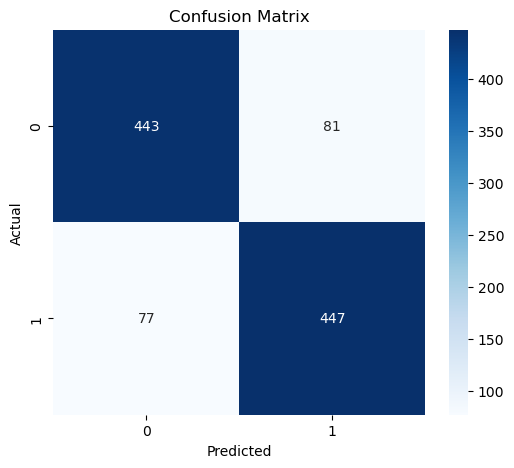

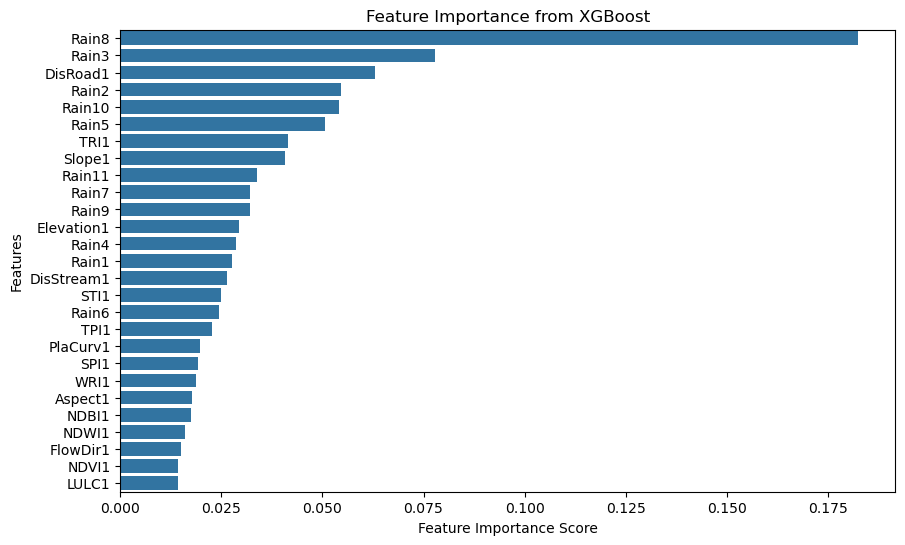

In [9]:
from sklearn.metrics import precision_score, recall_score
import shap
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score


# Define target variable
target_column = "Target_Var"

# Drop the target variable and wkt_geom column to get the features (X)
X = df.drop(columns=[target_column, "wkt_geom"])

# Assign the target variable (y)
y = df[target_column]

# Display the shapes of X and y
print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Handle missing values
df = df.fillna(0)

# Split dataset (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Define base model
xgb_base = xgb.XGBClassifier(eval_metric="logloss", random_state=42)


# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

grid_search = GridSearchCV(xgb_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Get the best model
best_xgb = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Predict and evaluate
y_pred = best_xgb.predict(X_test)
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)  # FIXED
report = classification_report(y_test, y_pred)  # FIXED

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)  # FIXED
print("\nClassification Report:\n", report)  # FIXED

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance (✅ FIXED: Using best_xgb instead of brt)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': best_xgb.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance from XGBoost')
plt.show()


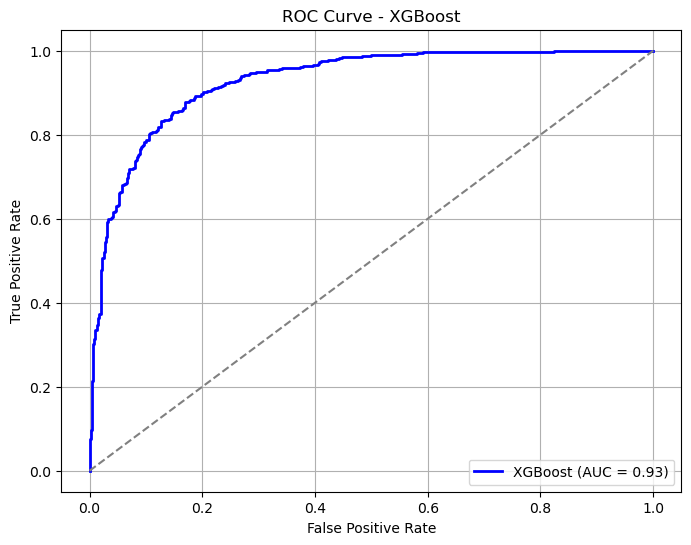

In [10]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities (already trained model: best_xgb)
y_prob = best_xgb.predict_proba(X_test)

# Binary Classification ROC
if len(np.unique(y_test)) == 2:
    auc_score = roc_auc_score(y_test, y_prob[:, 1])
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'XGBoost (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - XGBoost')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Multi-class ROC using One-vs-Rest strategy
else:
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc

    # Binarize the output
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    plt.figure(figsize=(10, 8))
    for i, class_id in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {class_id} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve - XGBoost')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


In [11]:
import pandas as pd

# Use existing variables from your notebook
df_xgb = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Prob': y_prob[:, 1],     # Probability for class 1 (flood-prone)
    'Predicted_Label': y_pred           # Final predicted class
})

# Save to your desired path
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\XGBoost_Landslide_Results.csv"
df_xgb.to_csv(save_path, index=False)


In [12]:
! pip install shap imbalanced-learn pandas scikit-learn matplotlib seaborn


🔹 SHAP values for first test sample:
 Aspect1       0.023769
Elevation1    0.064175
NDBI1         0.094465
NDVI1        -0.001010
NDWI1        -0.087557
TRI1         -0.473585
Slope1       -0.210936
PlaCurv1     -0.108278
SPI1         -0.345643
STI1         -0.320697
TPI1          0.052789
WRI1          0.000098
FlowDir1     -0.114668
Rain1        -0.312249
Rain2        -0.298483
Rain3         0.206821
Rain4         0.042991
Rain5         0.144868
Rain6        -0.016465
Rain7        -1.277342
Rain8        -2.083951
Rain9         0.032496
Rain10        0.058942
Rain11       -0.170173
DisRoad1      0.058967
DisStream1   -0.052977
LULC1         0.001198
Name: 0, dtype: float32

📊 Global SHAP Feature Importance:
        Feature  Mean_Absolute_SHAP
20       Rain8            0.819517
24    DisRoad1            0.520047
14       Rain2            0.316222
19       Rain7            0.313037
5         TRI1            0.295864
15       Rain3            0.293144
17       Rain5            0.205822


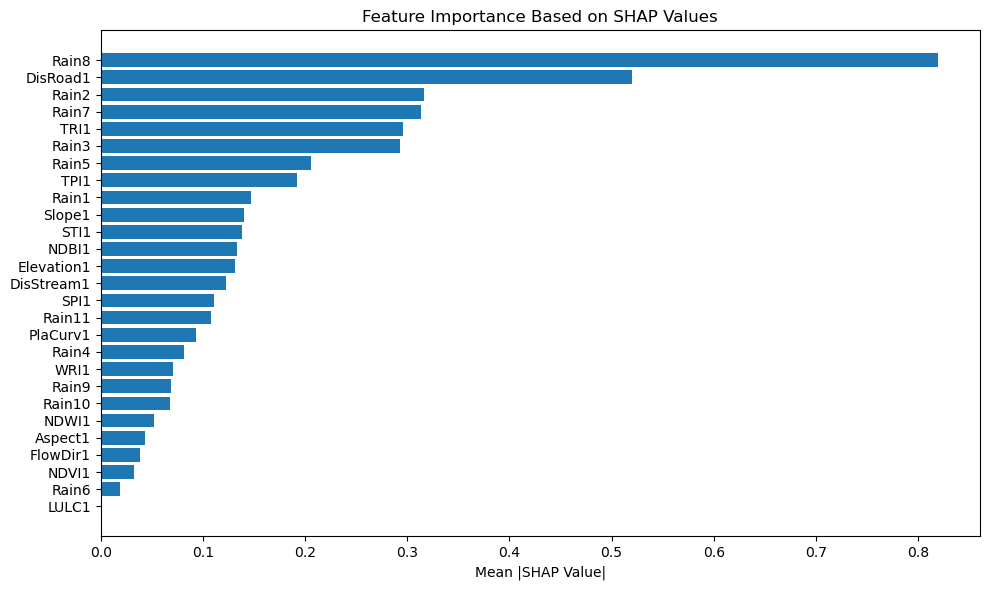

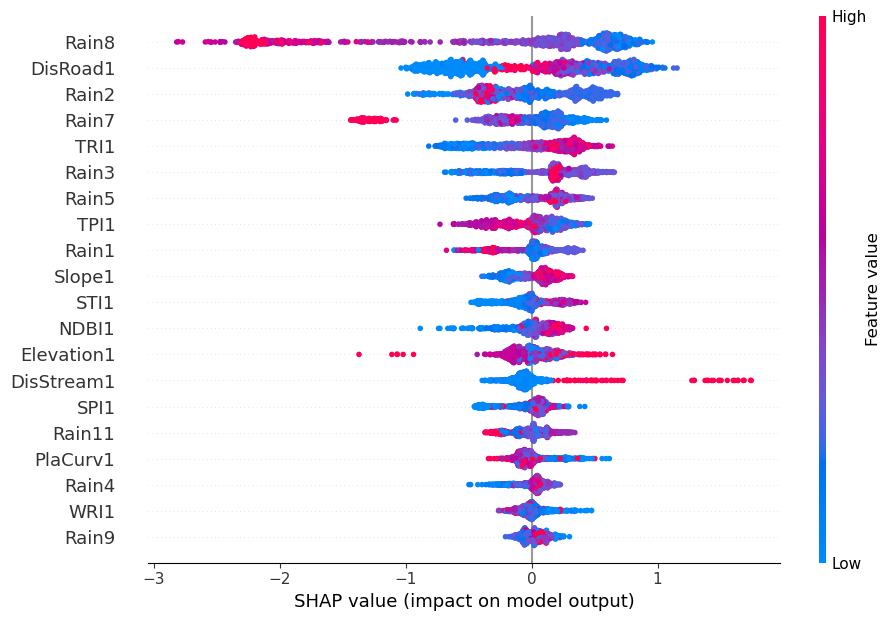

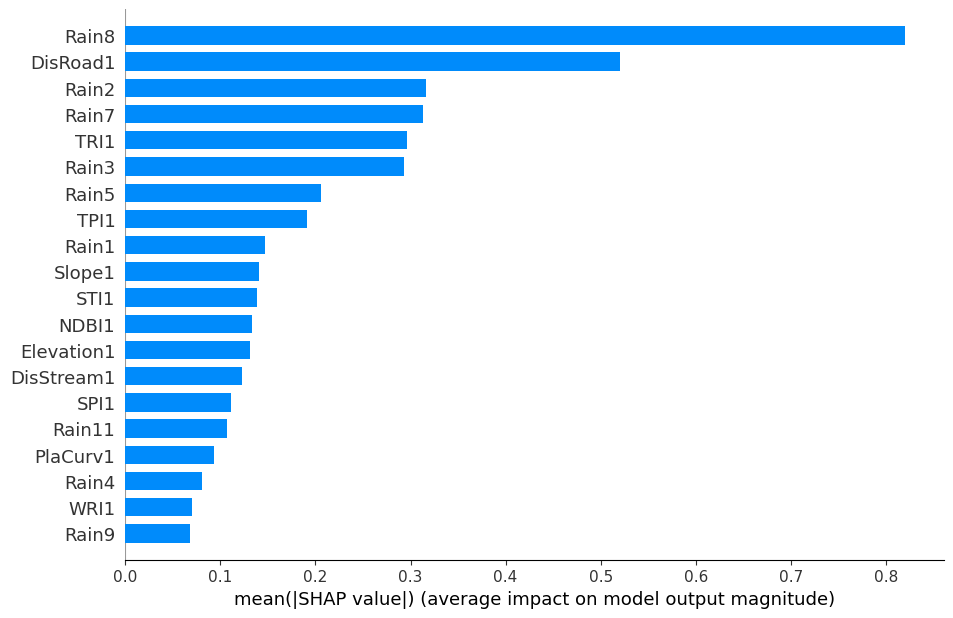

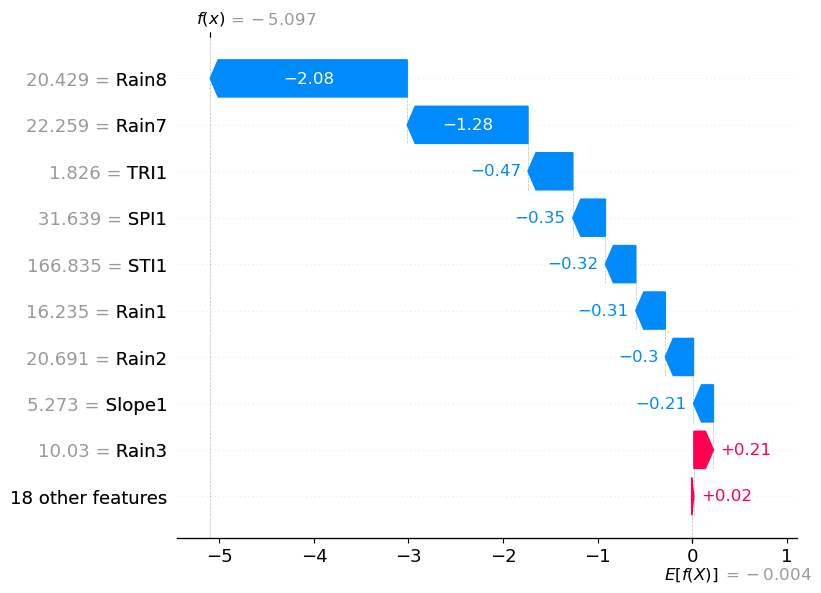

In [13]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Define output path
output_dir = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\SHAP\XGBoost(Landslide)"
os.makedirs(output_dir, exist_ok=True)

# Create SHAP explainer and compute SHAP values
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Save SHAP values per sample
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv(os.path.join(output_dir, "shap_values_all_samples.csv"), index=False)
print("\n🔹 SHAP values for first test sample:\n", shap_df.iloc[0])

# Global feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({'Feature': X_test.columns, 'Mean_Absolute_SHAP': mean_abs_shap})
shap_importance = shap_importance.sort_values(by='Mean_Absolute_SHAP', ascending=False)
shap_importance.to_csv(os.path.join(output_dir, "shap_global_importance.csv"), index=False)
print("\n📊 Global SHAP Feature Importance:\n", shap_importance)

# Bar plot - Mean Absolute SHAP
plt.figure(figsize=(10, 6))
plt.barh(shap_importance['Feature'], shap_importance['Mean_Absolute_SHAP'])
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance Based on SHAP Values')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "bar_plot_mean_absolute_shap.png"), dpi=300)
plt.show()

# --- Summary Plot (beeswarm) ---
shap.summary_plot(shap_values, X_test, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)  # Set a fixed size if needed
fig.savefig(os.path.join(output_dir, "summary_plot_beeswarm.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# --- Summary Plot (bar) ---
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(output_dir, "summary_plot_bar.png"), dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# Dependence plots - Save individually
for feature in X_test.columns:
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    fig = plt.gcf()
    fig.savefig(os.path.join(output_dir, f"dependence_plot_{feature}.png"), dpi=300, bbox_inches='tight')
    plt.close()

# Force Plot (interactive HTML, correct way)
shap.initjs()
force_plot = shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])
shap.save_html(os.path.join(output_dir, "force_plot_sample_0.html"), force_plot)  # ✅ this works

# Generate waterfall plot (inline show=True is OK)
waterfall_plot = shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns.tolist()
), show=False)

# Save manually from the current figure
fig = plt.gcf()
fig.savefig(os.path.join(output_dir, "waterfall_plot_sample_0.png"), dpi=300, bbox_inches='tight')
plt.show()
